# Day 12 — Introduction to Deep Learning

**Colab Notes + Hands-on Coding**

Topics: Artificial Neuron, Weights & Bias, Perceptron, Activation Functions, Neural Network, Forward Propagation, Loss, Gradient Descent, Epoch, Batch, Iteration, First Keras Neural Network.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 2. Artificial Neuron

A neuron calculates:

`z = w1*x1 + w2*x2 + ... + b`

Then an activation function is applied.

In [2]:
x = np.array([2, 3])
w = np.array([0.5, 0.8])
b = 1

z = np.dot(x, w) + b

print("Weighted Sum:", z)


Weighted Sum: 4.4


## 3. Step Activation

For a basic perceptron:

`z >= 0 → 1`

`z < 0 → 0`

In [3]:
def step_function(x):
    return 1 if x >= 0 else 0

print("Output:", step_function(z))


Output: 1


## 4. Simple Perceptron

In [4]:
def perceptron_predict(study_hours, attendance, weights, bias):
    x = np.array([study_hours, attendance])
    z = np.dot(x, weights) + bias
    return step_function(z)

weights = np.array([0.5, 0.05])
bias = -4

prediction = perceptron_predict(7, 85, weights, bias)

print("Prediction:", prediction)


Prediction: 1


## 5. Sigmoid

Sigmoid maps values to a range between 0 and 1 and is commonly used for binary classification outputs.

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

values = np.array([-5, -2, 0, 2, 5])
print(sigmoid(values))


[0.00669285 0.11920292 0.5        0.88079708 0.99330715]


### Sigmoid Visualization

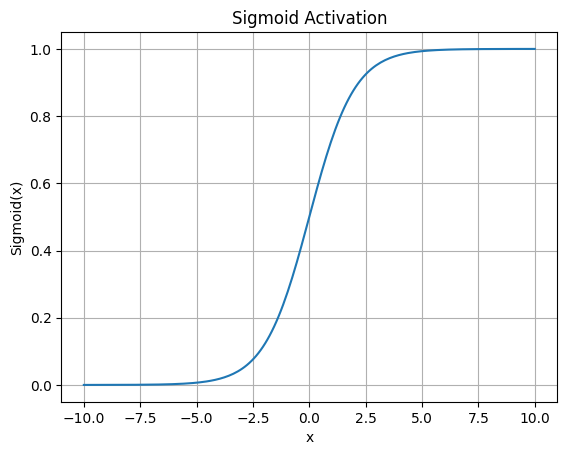

In [6]:
x = np.linspace(-10, 10, 200)
plt.plot(x, sigmoid(x))
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Activation")
plt.grid()
plt.show()


## 6. ReLU

`ReLU(x) = max(0, x)`

Commonly used in hidden layers.

In [7]:
def relu(x):
    return np.maximum(0, x)

print(relu(np.array([-5, -2, 0, 2, 5])))


[0 0 0 2 5]


### ReLU Visualization

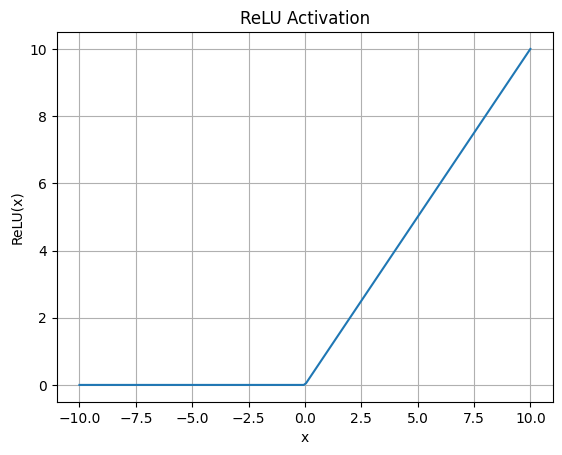

In [8]:
x = np.linspace(-10, 10, 200)
plt.plot(x, relu(x))
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.title("ReLU Activation")
plt.grid()
plt.show()


## 7. Tanh

In [9]:
values = np.array([-3, -1, 0, 1, 3])
print(np.tanh(values))


[-0.99505475 -0.76159416  0.          0.76159416  0.99505475]


## 8. Softmax

In [10]:
def softmax(x):
    exp_values = np.exp(x - np.max(x))
    return exp_values / np.sum(exp_values)

scores = np.array([2.0, 1.0, 0.1])
probabilities = softmax(scores)

print("Probabilities:", probabilities)
print("Sum:", probabilities.sum())


Probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0


## 9. Compare Activation Functions

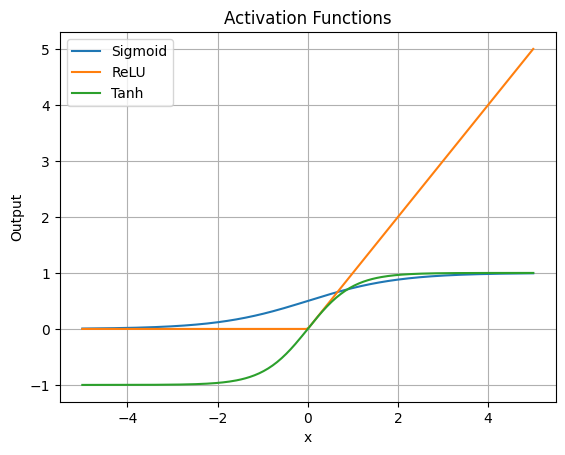

In [11]:
x = np.linspace(-5, 5, 200)

plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, np.tanh(x), label="Tanh")

plt.xlabel("x")
plt.ylabel("Output")
plt.title("Activation Functions")
plt.legend()
plt.grid()
plt.show()


# PART B — FORWARD PROPAGATION

`Input → Hidden Layer → Activation → Output Layer → Prediction`

In [12]:
x = np.array([2.0, 3.0])

W_hidden = np.array([
    [0.5, 0.2],
    [0.4, 0.7]
])
b_hidden = np.array([0.1, 0.2])

hidden_z = np.dot(x, W_hidden) + b_hidden
hidden_output = relu(hidden_z)

W_output = np.array([0.6, 0.8])
b_output = 0.1

output_z = np.dot(hidden_output, W_output) + b_output
output = sigmoid(output_z)

print("Hidden Output:", hidden_output)
print("Final Output:", output)


Hidden Output: [2.3 2.7]
Final Output: 0.9744192116879924


# PART C — LOSS

For binary classification, Binary Cross-Entropy is commonly used.

Loss measures how wrong the prediction is.

In [13]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-7
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

for prediction in [0.1, 0.5, 0.8, 0.95]:
    print(
        "Prediction:", prediction,
        "| Loss:", binary_cross_entropy(1, prediction)
    )


Prediction: 0.1 | Loss: 2.3025850929940455
Prediction: 0.5 | Loss: 0.6931471805599453
Prediction: 0.8 | Loss: 0.2231435513142097
Prediction: 0.95 | Loss: 0.05129329438755058


# PART D — GRADIENT DESCENT

Gradient Descent updates parameters to reduce loss.

`new_weight = old_weight - learning_rate × gradient`

In [14]:
weight = 5.0
learning_rate = 0.1
gradient = 2.0

new_weight = weight - learning_rate * gradient

print("Old weight:", weight)
print("New weight:", new_weight)


Old weight: 5.0
New weight: 4.8


# PART E — EPOCH, BATCH & ITERATION

- **Epoch:** one complete pass through the training dataset
- **Batch:** group of training samples
- **Iteration:** one parameter update based on a batch

In [15]:
samples = 1000
batch_size = 100

iterations_per_epoch = int(np.ceil(samples / batch_size))

print("Samples:", samples)
print("Batch Size:", batch_size)
print("Iterations per Epoch:", iterations_per_epoch)


Samples: 1000
Batch Size: 100
Iterations per Epoch: 10


# PART F — FIRST NEURAL NETWORK WITH KERAS

We will classify the Iris dataset using a simple neural network.

Architecture:

`Input → Dense(ReLU) → Dense(ReLU) → Dense(Softmax)`

In [16]:
!pip -q install tensorflow


In [17]:
import tensorflow as tf
from tensorflow import keras

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical


## 10. Load Iris Dataset

In [18]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)


Features shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


## 11. Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (120, 4)
Testing: (30, 4)


## 12. Feature Scaling

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 13. One-Hot Encode Target

In [21]:
y_train_encoded = to_categorical(y_train, 3)
y_test_encoded = to_categorical(y_test, 3)

print(y_train_encoded[:5])


[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


## 14. Build Sequential Neural Network

In [22]:
model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 15. Compile the Model

Optimizer: Adam

Loss: Categorical Cross-Entropy

Metric: Accuracy

In [23]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


## 16. Train the Neural Network

In [24]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3125 - loss: 1.3110 - val_accuracy: 0.3750 - val_loss: 1.2066
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3333 - loss: 1.2601 - val_accuracy: 0.3750 - val_loss: 1.1678
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3542 - loss: 1.2125 - val_accuracy: 0.4167 - val_loss: 1.1307
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3854 - loss: 1.1677 - val_accuracy: 0.4167 - val_loss: 1.0950
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4896 - loss: 1.1225 - val_accuracy: 0.5000 - val_loss: 1.0610
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5104 - loss: 1.0827 - val_accuracy: 0.5000 - val_loss: 1.0280
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4896 - loss: 1.0432 - val_accuracy: 0.4583 - val_loss: 0.9969
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4479 - loss: 1.0056 - val_accuracy: 0.4167 - val_loss: 0.9657


## 17. Evaluate the Model

In [25]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_encoded,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.6249183416366577
Test Accuracy: 0.7666666507720947


## 18. Make Predictions

In [26]:
probabilities = model.predict(X_test)

predicted_classes = np.argmax(
    probabilities,
    axis=1
)

print("Predicted:", predicted_classes[:10])
print("Actual   :", y_test[:10])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Predicted: [0 2 1 1 0 2 0 0 2 2]
Actual   : [0 2 1 1 0 1 0 0 2 1]


## 19. Training vs Validation Accuracy

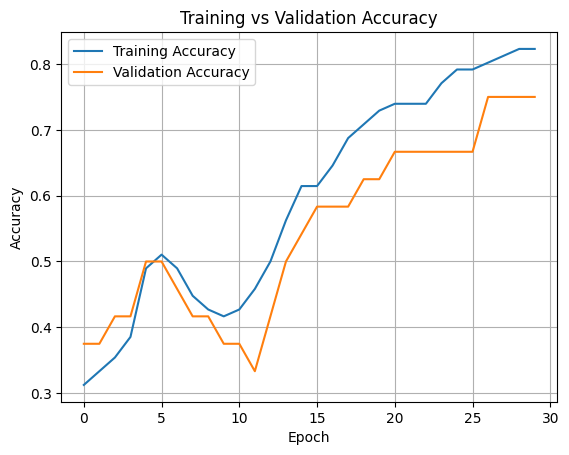

In [27]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


# 🎯 Day 12 Final Flow

`Input → Weights + Bias → Activation → Hidden Layers → Output → Loss → Gradient Descent → Updated Weights`

### Practice
1. Change perceptron weights.
2. Plot Sigmoid and ReLU.
3. Try different learning rates.
4. Change hidden neurons.
5. Change epochs.
6. Compare training and validation accuracy.